# Tutorial: Generate Images with MAI-Image-2 using Azure Credential

Audience:
- Developers testing MAI image generation from a notebook.

Prerequisites:
- Python kernel with `requests`, `azure-identity`, and `python-dotenv`.
- `AZURE_ENDPOINT` and `DEPLOYMENT_NAME` set in `.env`.
- Identity access to the Azure AI resource (for example via `az login` or managed identity).

Learning goals:
- Load project configuration from `.env`.
- Authenticate with `DefaultAzureCredential` (no API key).
- Generate and save a PNG image from a text prompt.


## Outline

1. Setup imports and environment values
2. Acquire a bearer token and call MAI image generation API
3. Decode and save image output
4. Display image inline


In [ ]:
# Run once per kernel if dependencies are missing.
# %pip install requests azure-identity python-dotenv


In [3]:
from __future__ import annotations

import base64
import os
from datetime import datetime
from pathlib import Path

import requests
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from dotenv import load_dotenv

load_dotenv()

endpoint = os.environ["AZURE_ENDPOINT"].rstrip("/")
deployment_name = os.environ["DEPLOYMENT_NAME"]

prompt = os.getenv("IMAGE_PROMPT", "A photorealistic image of a mountain lake at sunrise")
width = int(os.getenv("IMAGE_WIDTH", "1024"))
height = int(os.getenv("IMAGE_HEIGHT", "1024"))
base_output_path = Path(os.getenv("OUTPUT_PATH", "output.png"))
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
suffix = base_output_path.suffix or ".png"
output_path = base_output_path.with_name(f"{base_output_path.stem}_{timestamp}{suffix}")
output_path.parent.mkdir(parents=True, exist_ok=True)

print({
    "endpoint": endpoint,
    "deployment_name": deployment_name,
    "width": width,
    "height": height,
    "output_path": output_path.as_posix(),
})


{'endpoint': 'https://eval-foundry.services.ai.azure.com', 'deployment_name': 'MAI-IMAGE-2', 'width': 1024, 'height': 1024, 'output_path': 'output_20260406_085411.png'}


## Generate image (Azure credential auth, no API key)

This uses `DefaultAzureCredential` and requests an access token for the Cognitive Services scope.


In [4]:
token_provider = get_bearer_token_provider(
    DefaultAzureCredential(),
    "https://cognitiveservices.azure.com/.default",
)
token = token_provider()


4

In [5]:

url = f"{endpoint}/mai/v1/images/generations"
payload = {
    "model": deployment_name,
    "prompt": prompt,
    "width": width,
    "height": height,
}

response = requests.post(
    url,
    headers={
        "Content-Type": "application/json",
        "Authorization": f"Bearer {token}",
    },
    json=payload,
    timeout=180,
)
response.raise_for_status()
result = response.json()
len(result)


4

In [6]:
image_data = [item for item in result.get("data", []) if "b64_json" in item]
if not image_data:
    raise ValueError(f"Unexpected response format: {result}")

image_base64 = image_data[0]["b64_json"]
output_path.write_bytes(base64.b64decode(image_base64))
print(f"Image saved to {output_path.resolve()}")


Image saved to C:\repo\ai-foundry-craftkit\Model_Usecases\mai-image\output_20260406_085411.png


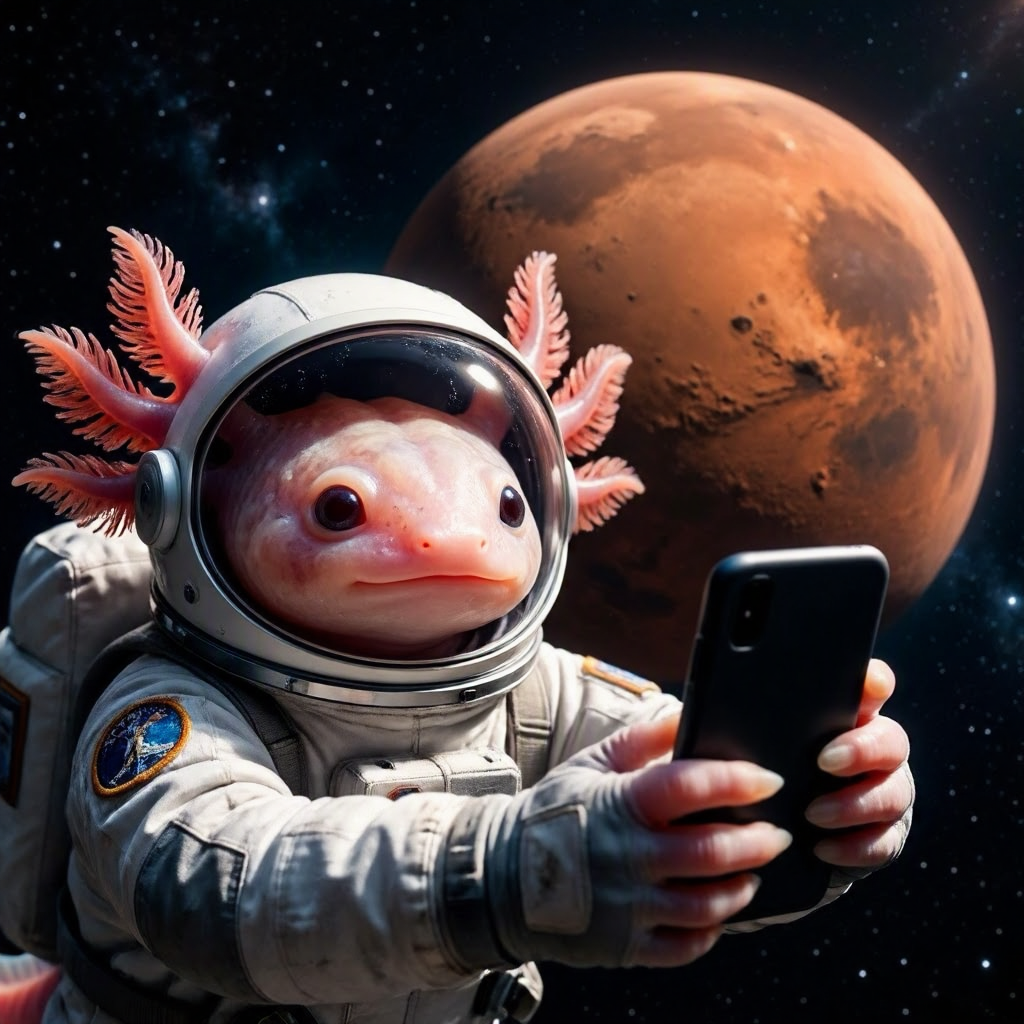

In [7]:
from IPython.display import Image, display

display(Image(filename=str(output_path)))


## Troubleshooting

- If authentication fails, run `az login` in a terminal and rerun cells.
- Confirm the signed-in identity has permission to call the Azure AI resource.
- Validate `AZURE_ENDPOINT` uses `https://<resource-name>.services.ai.azure.com`.
